## Runge-Kutta methods

Plot stability regions for various Runge-Kutta methods, just by calculating $|g|$ as a function of $k = \lambda \Delta t$ and then plotting the contour $|g| = 1$.

In [1]:
using Plots;

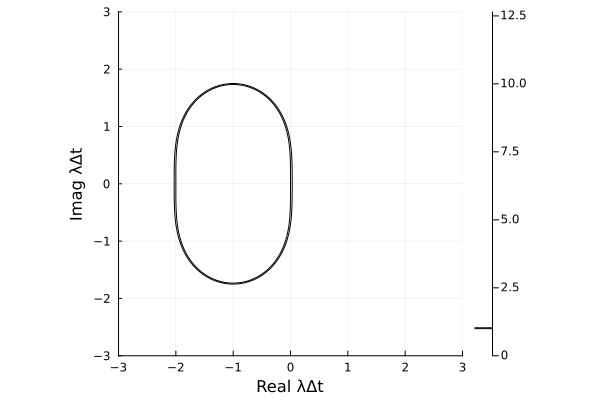

In [3]:
# Specify x range and number of points
x0 = -3.0
x1 =  3.0
Nx = 301

# Specify y range and number of points
y0 = -3.0
y1 =  3.0
Ny = 301

# Construct grid vectors
xv = range(x0, x1, length=Nx)
yv = range(y0, y1, length=Ny)

# Construct mesh 
x = repeat(reshape(xv, 1, :), Ny, 1)   # Ny × Nx
y = repeat(reshape(yv, :, 1), 1, Nx)   # Ny × Nx

# Complex grid
z = x .+ im .* y

# --- Choose method ---

# Runge-Kutta 2
g = 1 .+ z .+ 0.5 .* z.^2

# or Runge-Kutta 4
# g = 1 .+ z .+ 0.5 .* z.^2 .+ (1/6) .* z.^3 .+ (1/24) .* z.^4

# Magnitude
gmag = abs.(g)

# Contour levels
levels = [1.0, 1.03]

# Plot contour
contour(xv, yv, gmag;
    levels = levels,
    color = :black,
    linewidth = 1,
    xlabel = "Real λΔt",
    ylabel = "Imag λΔt",
    xlims = (x0, x1),
    ylims = (y0, y1),
    aspect_ratio = :equal,
    grid = true,
    label = false
)

Note that size of stability region increases with increased accuracy (unlike multi-step schemes)!

![caption](rkstab.png)

The construction of a Runge-Kutta method, whether explicit or implicit, can be systematically described by a _Butcher tableau_ (after John C. Butcher). We wil not get into these details, but it's nice to know for future exploration. See Wikipedia [here](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Explicit_Runge%E2%80%93Kutta_methods) and [here](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Implicit_Runge%E2%80%93Kutta_methods). 